# Project: Analyzing Real Estate Listings to Estimate Apartment Market Values

**Objective:** Conduct exploratory data analysis of apartment listings in Saint Petersburg and nearby localities, identify factors that affect prices, and test statistical hypotheses.

**[Dataset: real_estate_data.csv]**

### Data Description
- `total_images` — number of photos in the listing
- `last_price` — price when the listing was removed (rubles)
- `total_area` — total apartment area (m²)
- `first_day_exposition` — date the listing was published
- `rooms` — number of rooms
- `ceiling_height` — ceiling height (m)
- `floors_total` — total number of floors in the building
- `living_area` — living area (m²)
- `floor` — apartment floor
- `is_apartment` — whether the property is an apartment (Boolean)
- `studio` — whether the property is a studio (Boolean)
- `open_plan` — whether the property has an open-plan layout (Boolean)
- `kitchen_area` — kitchen area (m²)
- `balcony` — number of balconies
- `locality_name` — locality or city name
- `airports_nearest` — distance to the nearest airport (m)
- `cityCenters_nearest` — distance to the city centre (m)
- `parks_around3000` — number of parks within a 3 km radius
- `parks_nearest` — distance to the nearest park (m)
- `ponds_around3000` — number of bodies of water within a 3 km radius
- `ponds_nearest` — distance to the nearest body of water (m)
- `days_exposition` — number of days the listing remained online (from publication to removal)

## Part 1. Data Loading and Initial Preprocessing

Tasks:

1. Load the CSV data into a pandas DataFrame and create a copy of the DataFrame.
2. Inspect the DataFrame: display the first 5 rows (`head()`), general information (`info()`), and descriptive statistics (`describe()`).
3. Check for exact duplicate rows across the entire DataFrame, remove duplicates while keeping one copy, and record the number removed.
4. Plot histograms for the main numeric columns: `last_price`, `total_area`, `rooms`, `living_area`, and `kitchen_area` (use subplots).
5. Check for missing values in these key columns: `total_area`, `last_price`, `rooms`, `floors_total`, `balcony`, `ceiling_height`, `locality_name`, `first_day_exposition`, and `city_centers_nearest`.
6. Calculate the percentage of missing values in each listed column: (number of missing values / total number of rows) × 100%; compare the result with a 5% threshold.
7. Handle missing values according to each column's role in the analysis and the percentage missing:
   - If a column is not used in subsequent analysis (calculations, charts, or statistical tests), leave its missing values unchanged.
   - For columns used in the analysis:
     - `last_price`, `total_area`, `rooms`, `locality_name`, `ceiling_height`: if missingness is ≤ 5%, remove rows; if it is > 5%, fill with the median/mode (for example, the median price by locality and number of rooms).
     - `balcony`: fill missing values with 0 (no balcony).
     - `floors_total`: if missingness is < 5%, remove rows; otherwise, fill with the median for the locality.
     - `city_centers_nearest`: fill with the median distance for the locality.
8. Convert data types: `first_day_exposition` to datetime; categorical columns such as `locality_name` and `floor_type` to object.
9. After handling missing values, check the final row count, compare it with the original dataset size, record the number and percentage of rows removed, and list columns that still contain missing values with their percentages.

**Expected result:** A cleaned DataFrame with duplicates removed, missing values handled, and data types converted, ready for analysis.

In [ ]:
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
drive.mount('/content/drive')
import warnings
warnings.filterwarnings('ignore')
# Step 1: Load the data
df = pd.read_csv('/content/drive/MyDrive/real_estate_data.csv',sep ='\t')
# Step 2: General overview of the data
display(df.head())
print(df.info())
print(df.describe())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.0,2019-03-07T00:00:00,3,2.70,16.0,51.0,8,NaN,...,25.0,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.4,2018-12-04T00:00:00,1,NaN,11.0,18.6,1,NaN,...,11.0,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.0,2015-08-20T00:00:00,2,NaN,5.0,34.3,4,NaN,...,8.3,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.0,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.0,2018-06-19T00:00:00,2,3.03,14.0,32.0,13,NaN,...,41.0,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

0
23699


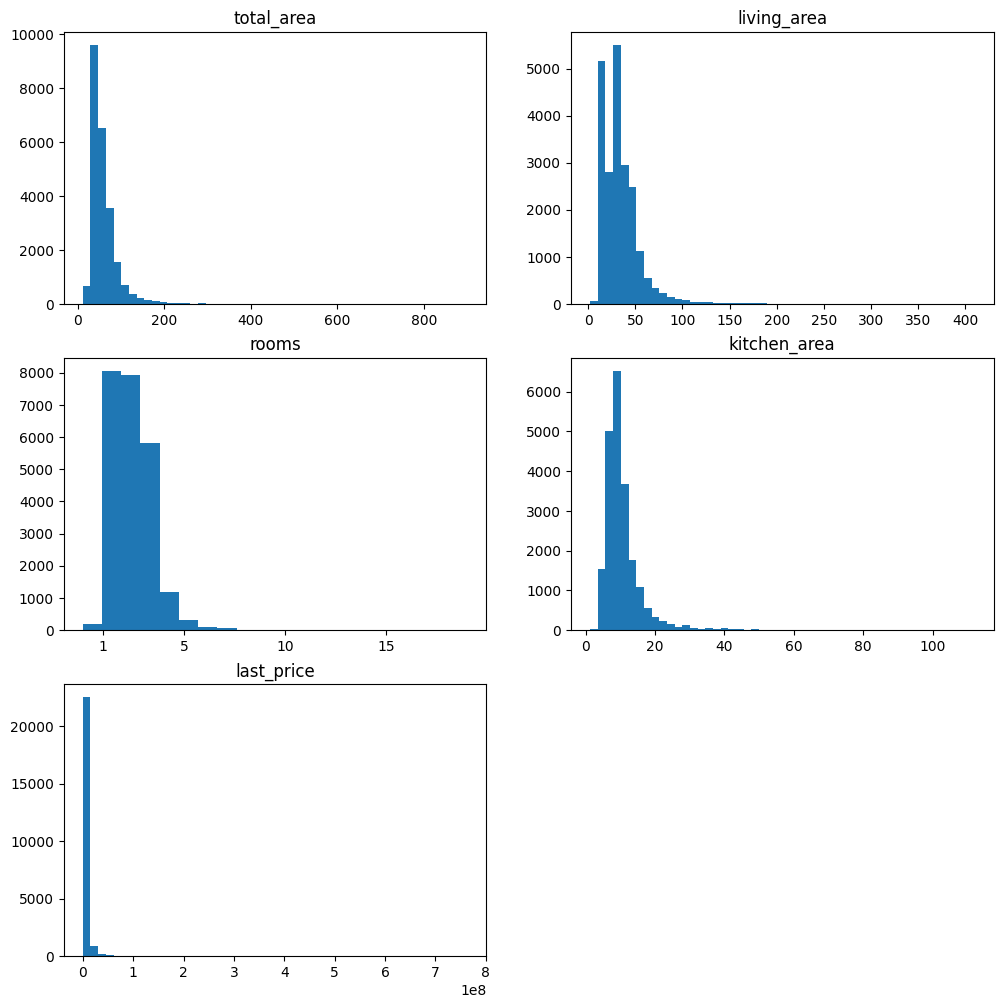

0        False
1        False
2        False
3        False
4        False
         ...  
23694    False
23695    False
23696    False
23697    False
23698    False
Name: last_price, Length: 23699, dtype: bool
0        False
1        False
2        False
3        False
4        False
         ...  
23694    False
23695    False
23696    False
23697    False
23698    False
Name: total_area, Length: 23699, dtype: bool
0        False
1        False
2        False
3        False
4        False
         ...  
23694    False
23695    False
23696    False
23697    False
23698    False
Name: rooms, Length: 23699, dtype: bool
0        False
1        False
2        False
3        False
4        False
         ...  
23694    False
23695    False
23696    False
23697    False
23698    False
Name: floors_total, Length: 23699, dtype: bool
0         True
1        False
2        False
3        False
4         True
         ...  
23694     True
23695     True
23696     True
23697    False
23698     Tru

In [ ]:
# Step 3: Check for duplicate rows
df1= df.duplicated().sum() # number of duplicate rows
df = df.drop_duplicates()
print(df1)
print(len(df))
# Step 4: Histograms for the main numeric columns
fig, ax = plt.subplots(3,2,figsize =(12,12))
ax[0,0].hist(df['total_area'],bins = 50)
ax[1,0].hist(df['rooms'],bins=20)
ax[0,1].hist(df['living_area'],bins = 50)
ax[1,1].hist(df['kitchen_area'],bins = 50)
ax[2,0].hist(df['last_price'],bins=50)
ax[2,1].set_visible(False)
ax[0,0].set_title('total_area')
ax[1,0].set_title('rooms')
ax[0,1].set_title('living_area')
ax[1,1].set_title('kitchen_area')
ax[1,0].set_xticks([1,5,10,15])
ax[2,0].set_title('last_price')
plt.show()

# Step 5: Find missing values
print(df['last_price'].isnull())
print(df['total_area'].isnull())
print(df['rooms'].isnull())
print(df['floors_total'].isnull())
print(df['balcony'].isnull())
print(df['ceiling_height'].isnull())
print(df['locality_name'].isnull())
print(df['first_day_exposition'].isnull())
print(df['cityCenters_nearest'].isnull())

# Step 6: Calculate the percentage of missing values in each column
print('last_price',df['last_price'].isnull().sum()/ len(df)*100)
print('total_area',df['total_area'].isnull().sum()/ len(df)*100)
print('rooms',df['rooms'].isnull().sum()/ len(df)*100)
print('floors_total',df['floors_total'].isnull().sum()/ len(df)*100)
print('balcony',df['balcony'].isnull().sum()/ len(df)*100)
print('ceiling_height',df['ceiling_height'].isnull().sum()/ len(df)*100)
print('locality_name',df['locality_name'].isnull().sum()/ len(df)*100)
print('first_day_exposition',df['first_day_exposition'].isnull().sum()/ len(df)*100)
print('cityCenters_nearest',df['cityCenters_nearest'].isnull().sum()/ len(df)*100)

After calculating the percentage of missing values in the nine columns, compare the results with the 5% threshold:

**Columns with less than 5% missing values** (rows can be removed): `last_price`, `total_area`, `rooms`, `floors_total`, `locality_name`, `first_day_exposition`

**Columns with more than 5% missing values** (values need to be filled): `balcony`, `ceiling_height`, `cityCenters_nearest`

In [ ]:
# Step 7: Handle missing values
df.dropna(subset=['total_area', 'last_price', 'rooms', 'floors_total', 'locality_name', 'first_day_exposition','days_exposition'], inplace=True)
df['ceiling_height'] = df['ceiling_height'].fillna(df['ceiling_height'].median())
df['balcony'] = df['balcony'].fillna(0)
df['cityCenters_nearest'] = df['cityCenters_nearest'].fillna(df['cityCenters_nearest'].median())

# Step 8: Convert data types
df['first_day_exposition']=pd.to_datetime(df['first_day_exposition'],errors='coerce',format ='mixed',yearfirst=True)
df['locality_name'] = df['locality_name'].astype('object')
# There is no floor_type column at this stage
# Step 9: Summary statistics after preprocessing
first_df = pd.read_csv('/content/drive/MyDrive/colab đại học/real_estate_data.csv',sep ='\t')
deleted_rows = len(first_df) - len(df)
percent_rows = (deleted_rows / len(first_df)) * 100

print('Step 9')
print(f"Original number of rows: {len(first_df)}")
print(f"Number of rows after preprocessing: {len(df)}")
print(f"Rows removed: {deleted_rows}")
print(f"Percentage of rows lost: {round(percent_rows,2)}%")

df2 = df.isnull().sum() / len(df) * 100
print(df2) # Eight other columns still contain missing values; they are not removed

Step 9
Original number of rows: 23699
Number of rows after preprocessing: 20394
Rows removed: 3305
Percentage of rows lost: 13.95%
total_images             0.000000
last_price               0.000000
total_area               0.000000
first_day_exposition     0.000000
rooms                    0.000000
ceiling_height           0.000000
floors_total             0.000000
living_area              8.188683
floor                    0.000000
is_apartment            87.815044
studio                   0.000000
open_plan                0.000000
kitchen_area             9.919584
balcony                  0.000000
locality_name            0.000000
airports_nearest        22.844954
cityCenters_nearest      0.000000
parks_around3000        22.737080
parks_nearest           66.230264
ponds_around3000        22.737080
ponds_nearest           61.645582
days_exposition          0.000000
dtype: float64


## Part 2. Working with Dates and Creating New Features

**Tasks:**

1. Add the following columns to `df`:
   - `year` — year the listing was published;
   - `month` — month the listing was published;
   - `weekday` — day of the week (0 = Monday, 6 = Sunday);
   - `day` — day of the month the listing was published.
2. Plot bar charts showing the distribution of listings by year, month, and day of the week.
3. Add other useful columns to `df`:
   - `price_per_sqm` — price per square metre, calculated by dividing the listing price by total area and rounding to two decimal places;
   - `distance_km` — distance to the city centre converted from metres to kilometres and rounded to the nearest whole number;
   - `floor_type` — “ground/first floor” if `floor` = 1, “top floor” if `floor` = `floors_total`, and “other” in all other cases.

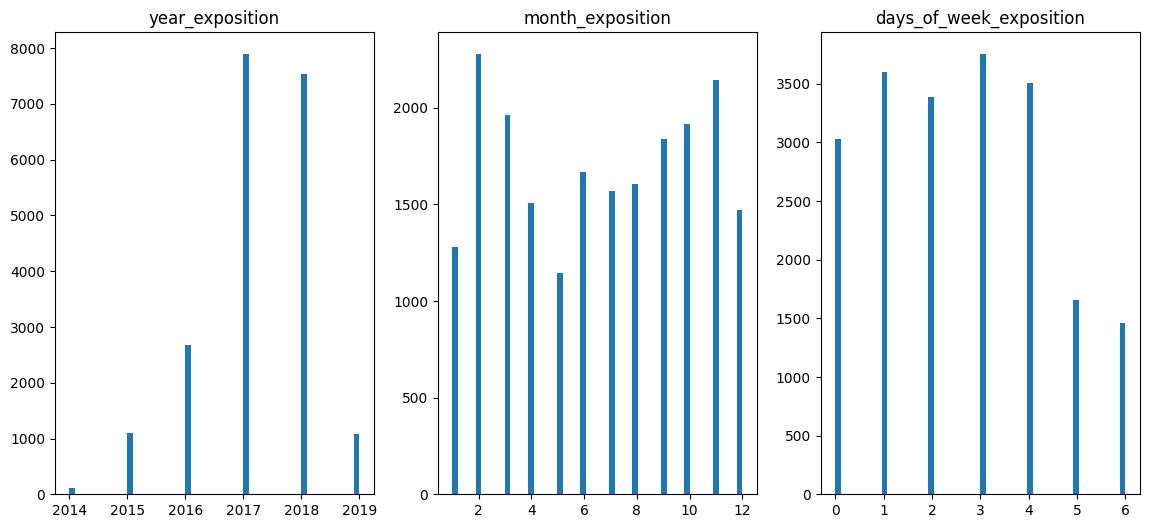

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,ponds_around3000,ponds_nearest,days_exposition,year_exposition,month_exposition,days_of_week_exposition,day_of_month_exposition,price_per_sqm,distance_km,floor_type
1,7,3350000.0,40.40,2018-12-04,1,2.65,11.0,18.6,1,NaN,...,0.0,NaN,81.0,2018,12,1,4,82920.79,19.0,Ground/first floor
2,10,5196000.0,56.00,2015-08-20,2,2.65,5.0,34.3,4,NaN,...,2.0,574.0,558.0,2015,8,3,20,92785.71,14.0,Other
3,0,64900000.0,159.00,2015-07-24,3,2.65,14.0,NaN,9,NaN,...,3.0,234.0,424.0,2015,7,4,24,408176.10,7.0,Other
4,2,10000000.0,100.00,2018-06-19,2,3.03,14.0,32.0,13,NaN,...,1.0,48.0,121.0,2018,6,1,19,100000.00,8.0,Other
5,10,2890000.0,30.40,2018-09-10,1,2.65,12.0,14.4,5,NaN,...,NaN,NaN,55.0,2018,9,0,10,95065.79,13.0,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23691,11,9470000.0,72.90,2016-10-13,2,2.75,25.0,40.3,7,NaN,...,1.0,806.0,519.0,2016,10,3,13,129903.98,4.0,Other
23692,2,1350000.0,30.00,2017-07-07,1,2.65,5.0,17.5,4,NaN,...,NaN,NaN,413.0,2017,7,4,7,45000.00,13.0,Other
23693,9,4600000.0,62.40,2016-08-05,3,2.60,9.0,40.0,8,NaN,...,1.0,675.0,239.0,2016,8,4,5,73717.95,34.0,Other
23695,14,3100000.0,59.00,2018-01-15,3,2.65,5.0,38.0,4,NaN,...,NaN,NaN,45.0,2018,1,0,15,52542.37,13.0,Other


In [ ]:
# Step 1: Add time-related features
df['year_exposition']  = df['first_day_exposition'].dt.year
df['month_exposition']  = df['first_day_exposition'].dt.month
df['days_of_week_exposition']  = df['first_day_exposition'].dt.day_of_week
df['day_of_month_exposition']  = df['first_day_exposition'].dt.day

# Step 2: Plot distributions by year, month, and day of the week
fig,ax=plt.subplots(1,3,figsize=(14,6))
ax[0].hist(df['year_exposition'],bins =50)
ax[1].hist(df['month_exposition'],bins =50)
ax[2].hist(df['days_of_week_exposition'],bins =50)

ax[0].set_title('year_exposition')
ax[1].set_title('month_exposition')
ax[2].set_title('days_of_week_exposition')
plt.show()

# Step 3: Add derived features
df['price_per_sqm']= round((df['last_price']/ df['total_area']),2)
df['distance_km']=round((df['cityCenters_nearest']/1000),0)
conditions = [df['floor'] == 1, df['floor'] == df['floors_total']] # List of two conditions
choices = ['Ground/first floor', 'Top floor']
df['floor_type'] = np.select(conditions, choices, default='Other') # The default value is used when neither condition is met
display(df)


## Results of Part 2

After adding time-related features, price per square metre, distance to the city centre, and floor type, and plotting their distributions, the following results were observed:

1. **By year:** The largest number of listings was recorded in 2017 and 2018. There were considerably fewer listings in the other years.
2. **By month:** Listing activity peaked in spring (February, March, and April) and autumn (October and November).
3. **By day of the week:** Listings were published more often on weekdays and least often on weekends (Saturday and Sunday).
4. **Price per square metre (`price_per_sqm`):** This calculated metric will be used in subsequent analyses.
5. **Distance to the city centre (`distance_km`):** Converted from metres to kilometres to make it easier to group apartments by distance from the centre.
6. **Floor type (`floor_type`):** Divided into three categories: “ground/first floor,” “top floor,” and “other.” This feature will help test hypotheses about the relationship between floor location and sale price.

All new features have been added, data types are appropriate, and no missing values remain in the analysed fields. The data are ready for exploratory data analysis in Part 3.

## Part 3.1. Exploratory Data Analysis (EDA)

1. Plot histograms or boxplots to examine distributions and identify anomalies in `total_area`, `last_price`, `price_per_sqm`, `distance_km`, and `ceiling_height`.
2. Handle anomalies:
   - Remove rows where `total_area` < 10 or > 200 m²;
   - Remove rows where `last_price` < 1e6 or > 50e6 rubles;
   - Remove rows with unusually low or high ceilings: `ceiling_height` < 2.2 or > 3.5 m.
3. Calculate the mean and median of `days_exposition`.

Describe the results in a Markdown cell.

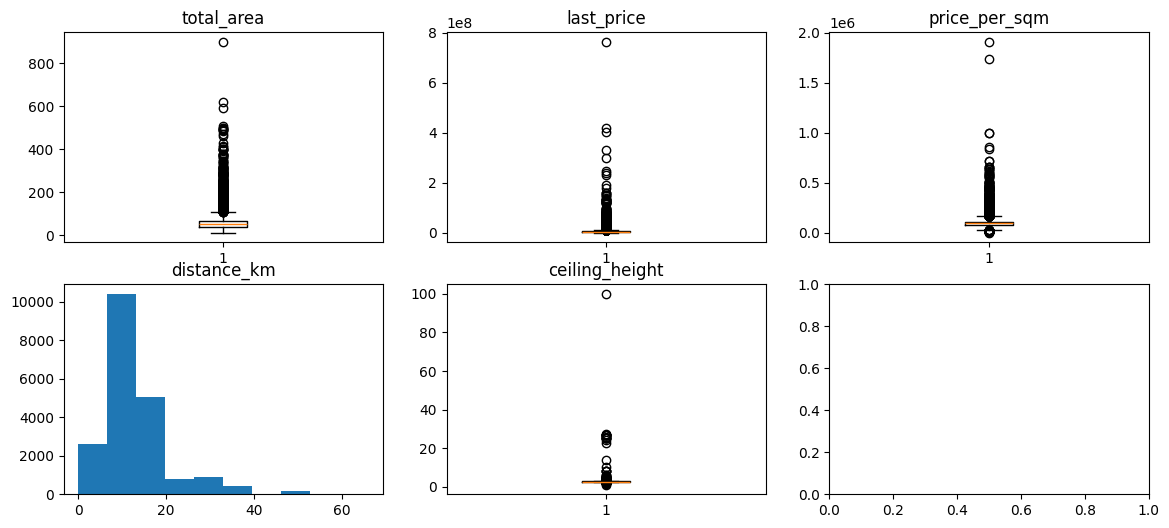

178.7137924030063
94.0


In [ ]:
# Step 1: Visualise distributions and anomalies
fig,ax = plt.subplots(2,3,figsize = (14,6))
ax[0,0].boxplot(df['total_area'])
ax[0,1].boxplot(df['last_price'])
ax[0,2].boxplot(df['price_per_sqm'])
ax[1,0].hist(df['distance_km'])
ax[1,1].boxplot(df['ceiling_height'])

ax[0,0].set_title('total_area')
ax[0,1].set_title('last_price')
ax[0,2].set_title('price_per_sqm')
ax[1,0].set_title('distance_km')
ax[1,1].set_title('ceiling_height')
plt.show()

# Step 2: Remove outliers
# Remove rows where total_area < 10 or > 200 m²
df = df[(df['total_area']>10) & (df['total_area']<200)]
# Remove rows where last_price < 1e6 or > 50e6 rubles
df = df[(df['last_price']>1e6) & (df['last_price']<50e6)]
# Remove rows with anomalous ceiling heights: ceiling_height < 2.2 or > 3.5 m
df = df[(df['ceiling_height']>2.2) & (df['ceiling_height']<3.5)]

# Step 3: Mean and median of days_exposition
print(df['days_exposition'].mean()) # 178
print(df['days_exposition'].median()) # 94

The boxplots and histograms revealed anomalies in three columns: `total_area`, `last_price`, and `ceiling_height`. After removing outliers according to the instructions, the boxplots became clearer and more representative.

The mean of `days_exposition` is substantially higher than the median (almost twice as high), indicating a right-skewed distribution, with some listings remaining online for a very long time.

### Part 3.2. Factors Affecting Price and Visualisation

1. **Price dynamics:**
   - Plot `last_price` by year;
   - Plot the average `price_per_sqm` by month for each year;
   - Build a heatmap of listing counts by year and month.
2. **Price by room count and floor type:** Create a violin plot of `price_per_sqm` by `rooms` and `floor_type`.
3. **Correlation analysis:** Calculate the correlation between `last_price` and the main features (`total_area`, `rooms`, `kitchen_area`, `ceiling_height`).
4. Identify the five localities with the largest number of listings and plot the average price per square metre for these localities.
5. Analyse the relationship between `price_per_sqm` and `distance_km`:
   - Group the data by `distance_km`;
   - Calculate the average price per square metre for each kilometre;
   - Plot a line chart.

Describe the results of the factor analysis and visualisations in a Markdown cell.

   last_year_exposition    last_price
0                  2016  5.736813e+06
1                  2017  5.532806e+06
2                  2018  5.468888e+06
3                  2019  6.063750e+06


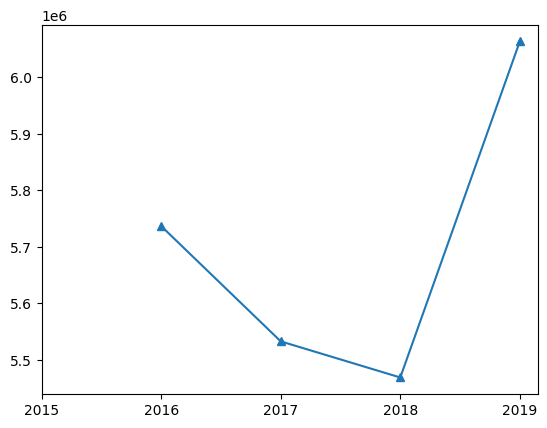

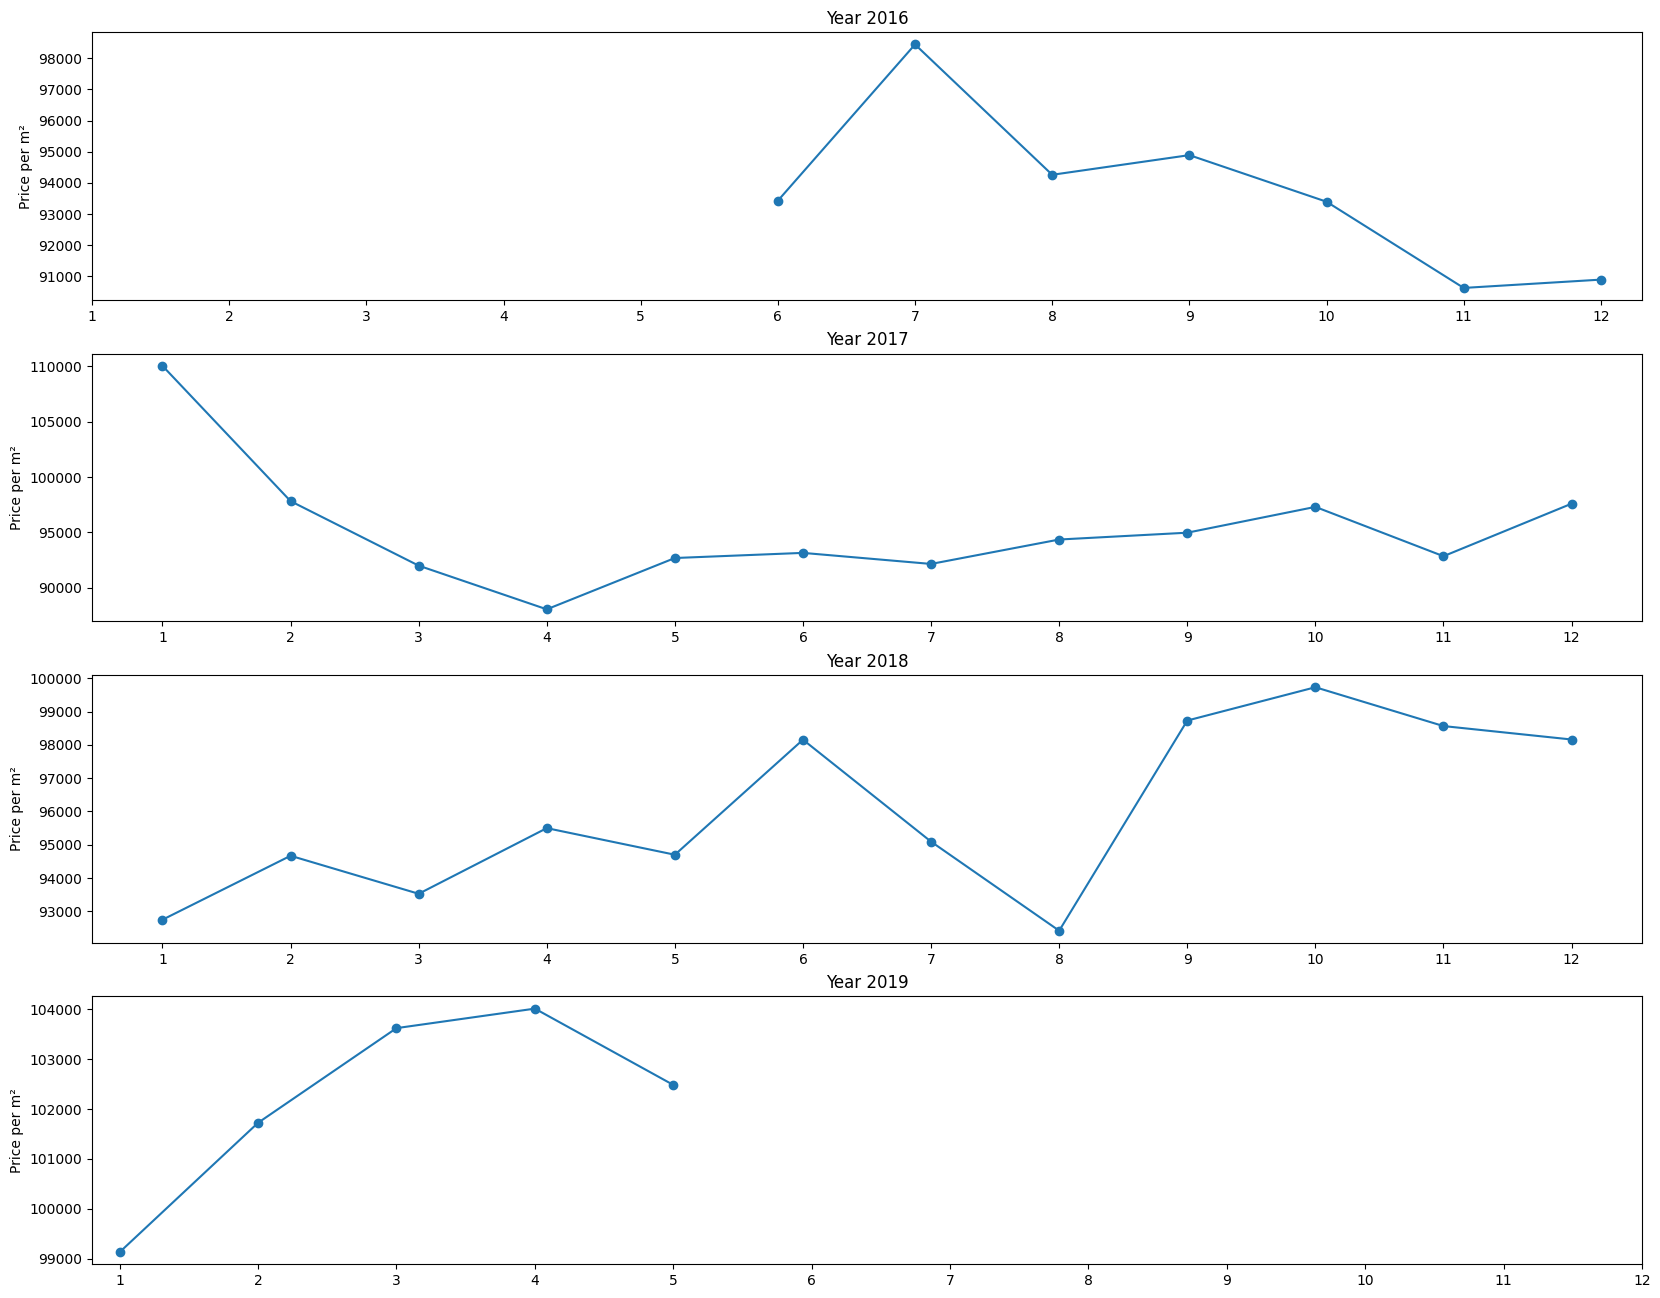

In [ ]:
# Step 1a: Price dynamics by year
df['last_day_exposition'] = df['first_day_exposition'] + pd.to_timedelta(df['days_exposition'],unit='D')
df['last_year_exposition'] = df['last_day_exposition'].dt.year
price_pivot = df.pivot_table(
    values='last_price', # calculate using last_price
    index='last_year_exposition',
    aggfunc='mean'
).reset_index()
print(price_pivot)
plt.plot(price_pivot['last_year_exposition'],price_pivot['last_price'],marker ='^')
plt.xticks(range(2015,2020))
plt.show()

# Step 1b: Average price per m² by month for each year
df['last_month_exposition'] = df['last_day_exposition'].dt.month
avg_price = df.groupby(['last_year_exposition', 'last_month_exposition'])['price_per_sqm'].mean().reset_index()
years=range(2016,2020)
fig,ax = plt.subplots(4,1,figsize=(20,16))
for i, year in enumerate(years):
    year_data = avg_price[avg_price['last_year_exposition'] == year]
    ax[i].plot(year_data['last_month_exposition'], year_data['price_per_sqm'], marker='o')
    ax[i].set_title(f'Year {year}')
    ax[i].set_ylabel('Price per m²')
    ax[i].set_xticks(range(1, 13))
plt.show()

last_month_exposition    1    2     3    4    5    6    7    8    9    10  \
last_year_exposition                                                        
2016                      0    0     0    0    0  232  505  356  258  196   
2017                    156  133   168  186  277  364  446  410  532  711   
2018                   1064  901  1046  910  702  481  536  778  903  980   
2019                    603  563   654  958   57    0    0    0    0    0   

last_month_exposition    11   12  
last_year_exposition              
2016                    121   92  
2017                    761  766  
2018                   1014  872  
2019                      0    0  


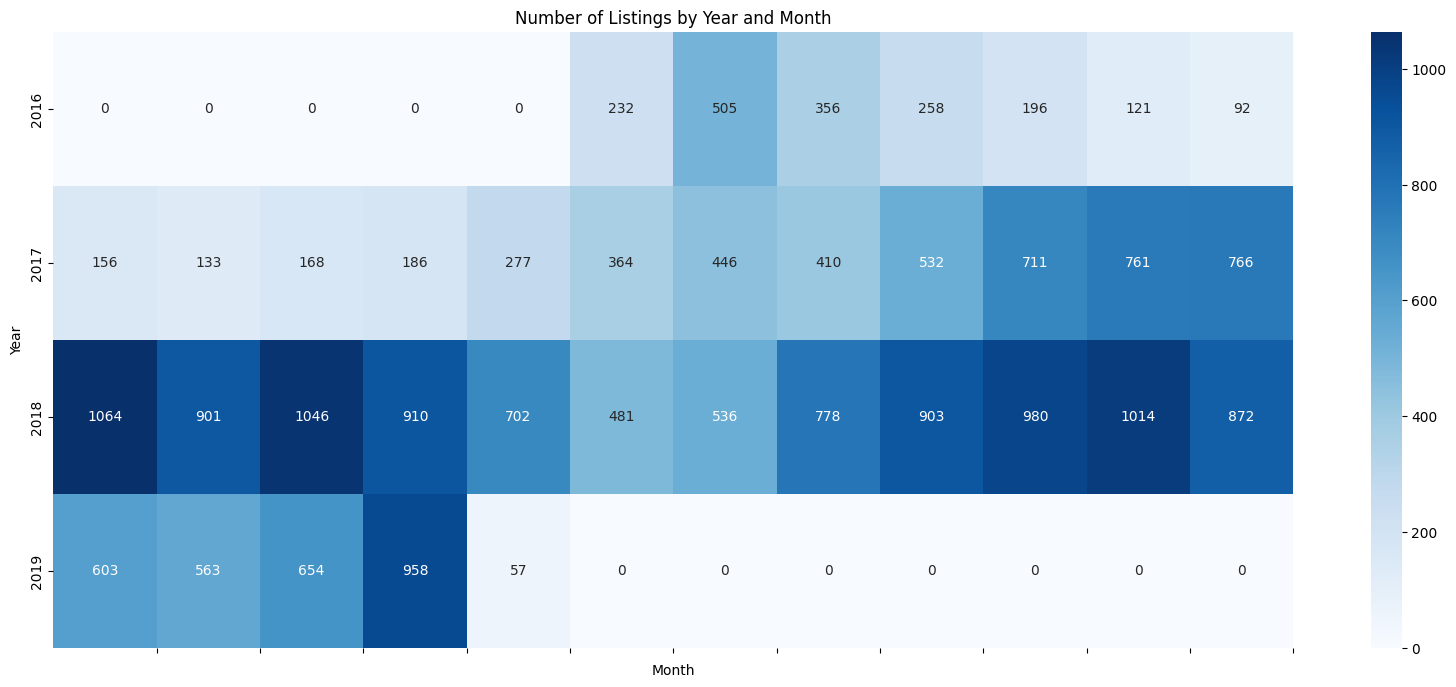

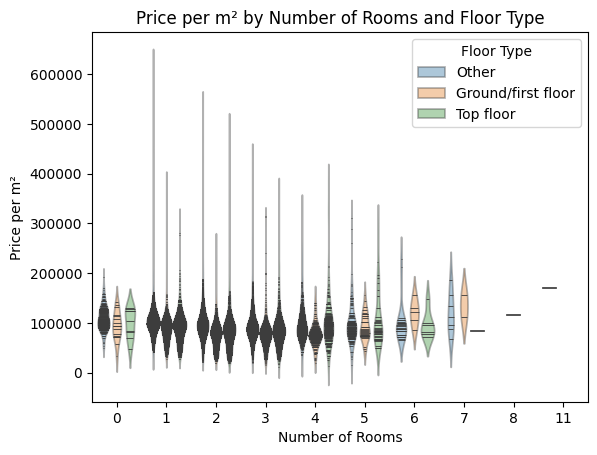

total_area        0.763115
rooms             0.467566
kitchen_area      0.581270
ceiling_height    0.389738
dtype: float64


In [ ]:
# Step 1c: Heatmap of listing counts by year and month
pivot_counts = df.pivot_table( # Rows: year listing was removed; columns: removal month; values: number of listings
    index='last_year_exposition',
    columns='last_month_exposition',
    values='last_price',
    aggfunc='count'
).fillna(0).astype(int)
print(pivot_counts)
plt.figure(figsize=(20, 8))
sns.heatmap(pivot_counts,annot=True,fmt='d',cmap='Blues')
plt.title('Number of Listings by Year and Month')
plt.xlabel('Month')
plt.ylabel('Year')
plt.xticks(ticks=range(1,13))
plt.show()
# Step 2: Violin plot of price per m² by room count and floor type
sns.violinplot(data= df,x ='rooms',y= 'price_per_sqm',hue = 'floor_type',alpha = 0.4,inner ='stick')
plt.title('Price per m² by Number of Rooms and Floor Type')
plt.xlabel('Number of Rooms')
plt.ylabel('Price per m²')
plt.legend(title='Floor Type')
plt.show()
# Step 3: Correlation of last_price with key features
cor = df[["total_area", "rooms", "kitchen_area", "ceiling_height"]].corrwith(df['last_price'])
print(cor)


**Findings 3.2**

**1.** The yearly `last_price` chart shows that listing volume was high in 2017–2018, while the average sale price was lower than in 2015 and 2019. This may be because the data for 2015 and 2019 cover only six months.

The monthly average price-per-square-metre chart shows a general upward trend towards the end of the year, around September–October (autumn).

The heatmap of listing counts confirms that activity in 2017 and 2018 was substantially higher than in the other years.

**2.** The violin plot is discussed separately in Part 4.

**3.** Only `total_area` has a relatively strong correlation with `last_price` (r = 0.7); the other features have much weaker correlations.

       locality_name  count           mean
32   Санкт-Петербург  13123  109534.215509
240   посёлок Мурино    513   85711.577856
270   посёлок Шушары    406   77846.547660
3         Всеволожск    335   68515.952209
13           Колпино    307   74763.339316


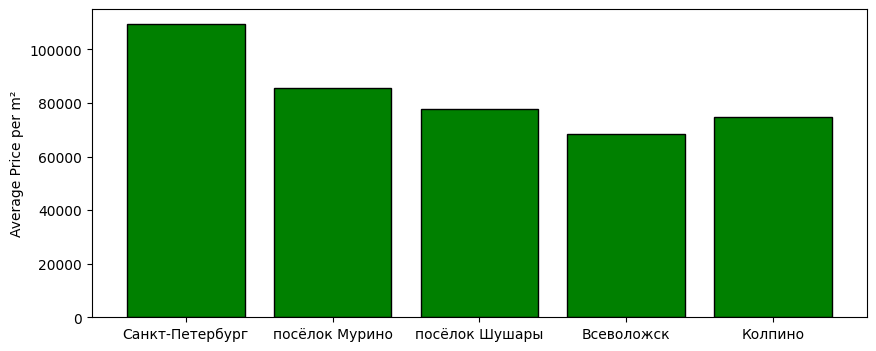

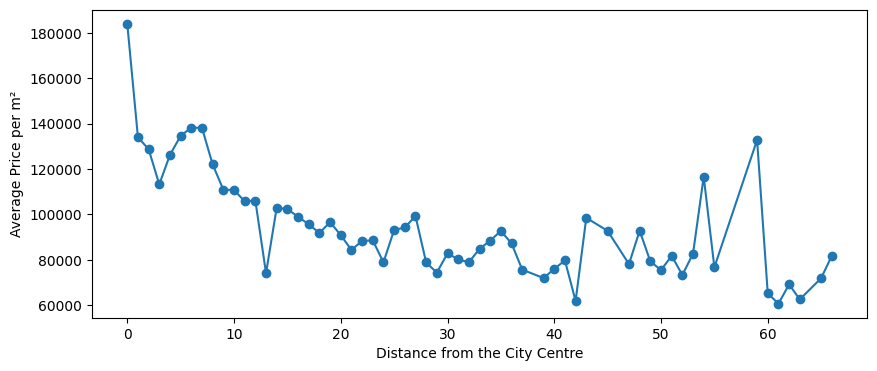

In [ ]:
# Step 4: Top five localities by number of listings
count_by_location = df.pivot_table(index = 'locality_name' , values='price_per_sqm', aggfunc={'price_per_sqm':['count','mean']}).reset_index()
count_by_location.sort_values(by='count',inplace=True, ascending = False)
top_by_location = (count_by_location.head(5))
print(top_by_location)
# Step 5: Average price per m² in the top five localities
plt.figure(figsize = (10,4))
plt.bar(top_by_location['locality_name'],top_by_location['mean'],color = 'g',edgecolor ='black')
plt.ylabel('Average Price per m²')
plt.show()
# Step 6: Relationship between price_per_sqm and distance_km
price_by_distance = df.pivot_table(index = 'distance_km', values = 'price_per_sqm',aggfunc = 'mean').reset_index()
plt.figure(figsize=(10,4))
plt.plot(price_by_distance['distance_km'],price_by_distance['price_per_sqm'],marker = 'o')
plt.ylabel('Average Price per m²')
plt.xlabel('Distance from the City Centre')
plt.show()


**Finding 4:** Top five localities by number of listings:
- Saint Petersburg — 15,059
- Murino settlement — 518
- Shushary settlement — 438
- Vsevolozhsk — 393
- Pushkin — 355

**Finding 5:** Pushkin has a relatively small number of listings, yet its price per square metre is close to that of Saint Petersburg, one of the most active and expensive markets.

**Finding 6:** The average price per square metre decreases with distance from the city centre. At the centre (0 km), the price is highest at approximately RUB 119,000/m². Within 0–5 km, it drops sharply to around RUB 40,000–50,000/m². Beyond 40 km, the price rises slightly, possibly because of demand for suburban land and properties suitable for dachas and cottages.

**Overall conclusion:** The farther from the centre, the lower and more stable the price. Each additional kilometre is associated with a noticeable price decrease, especially within the first 5 km.

## Part 4. Statistical Analysis: Z-Test and t-Test

### Part 4.1. Comparing Proportions: The Share of Open-Plan Apartments Is Higher in Buildings with at Least 10 Floors than in Buildings with 5 Floors or Fewer

- **H₀:** The proportions are equal.
- **H₁:** The proportion is higher in high-rise buildings.

**Rationale:** Modern multi-storey residential complexes tend to offer apartments with flexible layouts.

**Tasks:**

1. Create a binary variable for open-plan layouts: `open_plan_binary` = 1 if `open_plan` = True, otherwise 0.
2. Filter two groups:
   - Group A (low-rise buildings): `floors_total` ≤ 5
   - Group B (high-rise buildings): `floors_total` ≥ 10
3. Before testing, remove rows with missing values in `open_plan_binary` using `dropna()`.
4. Conduct a Z-test (`proportions_ztest`):
   - `count`: array with the number of apartments with the feature in groups A and B;
   - `nobs`: array with the total number of apartments in groups A and B;
   - `alternative = 'larger'` (one-sided test: the proportion in group B is higher).
5. Interpret the result (if p-value < 0.05, reject H₀).
6. Create a bar chart with two bars.

### Part 4.2. Comparing Average Prices

**Hypothesis:** The average price per square metre in Saint Petersburg is higher than in other localities.

- **H₀:** The average prices are equal.
- **H₁:** The average price in Saint Petersburg is higher.

**Tasks:**

1. Split the data into two groups:
   - Saint Petersburg: `locality_name == 'Санкт-Петербург'`
   - All other localities.
2. Before testing, remove rows with missing values in `price_per_sqm`.
3. Check distribution normality and equality of variances.
4. Conduct a two-sample t-test with the alternative hypothesis that the average price in Saint Petersburg is higher.
5. Interpret the p-value and compare the groups using a boxplot.

p-value: 6.814337673780134e-08


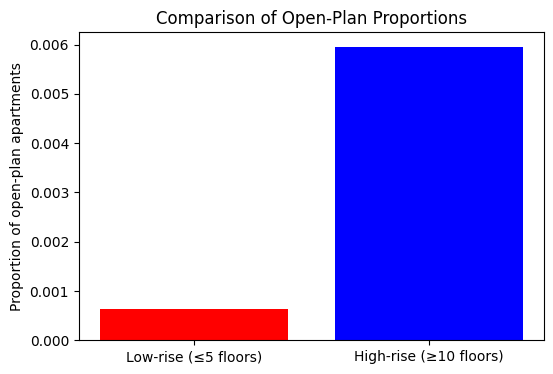

In [ ]:
from statsmodels.stats import proportion
# Part 4.1
# Step 1: Create a binary variable
condition = [df['open_plan']==True]
df['open_plan_binary'] =np.select(condition,[1],default = 0)
# Step 2: Create the two groups
low_floor = df[(df['floors_total']<=5)]
high_floor =  df[(df['floors_total']>=10)]
# Step 3: Remove rows with missing values in open_plan_binary
low_floor = low_floor.dropna(subset= 'open_plan_binary').reset_index()
high_floor=  high_floor.dropna(subset= 'open_plan_binary').reset_index()
# Step 4: Z-test (proportions_ztest)
count_low_floor = low_floor['open_plan_binary'].sum()
count_high_floor = high_floor['open_plan_binary'].sum()
z,p = proportion.proportions_ztest(count=[count_high_floor,count_low_floor],
                            nobs=[len(high_floor),len(low_floor)],alternative = 'larger') # The first group is expected to have a higher proportion
print('p-value:',p)
# Step 5: Interpretation
# Step 6: Bar chart
rates = [count_low_floor / len(low_floor), count_high_floor / len(high_floor)]
labels = ['Low-rise (≤5 floors)', 'High-rise (≥10 floors)']
plt.figure(figsize=(6, 4))
plt.bar(labels, rates, color=['red', 'blue'])
plt.ylabel('Proportion of open-plan apartments')
plt.title('Comparison of Open-Plan Proportions')
plt.show()


**Finding 4.1:** p-value = 2.756e-08 < 0.05, so H₀ is rejected. There is sufficient evidence that the proportion of open-plan apartments in high-rise modern buildings is statistically significantly higher than in low-rise buildings, where fixed layouts are more common.

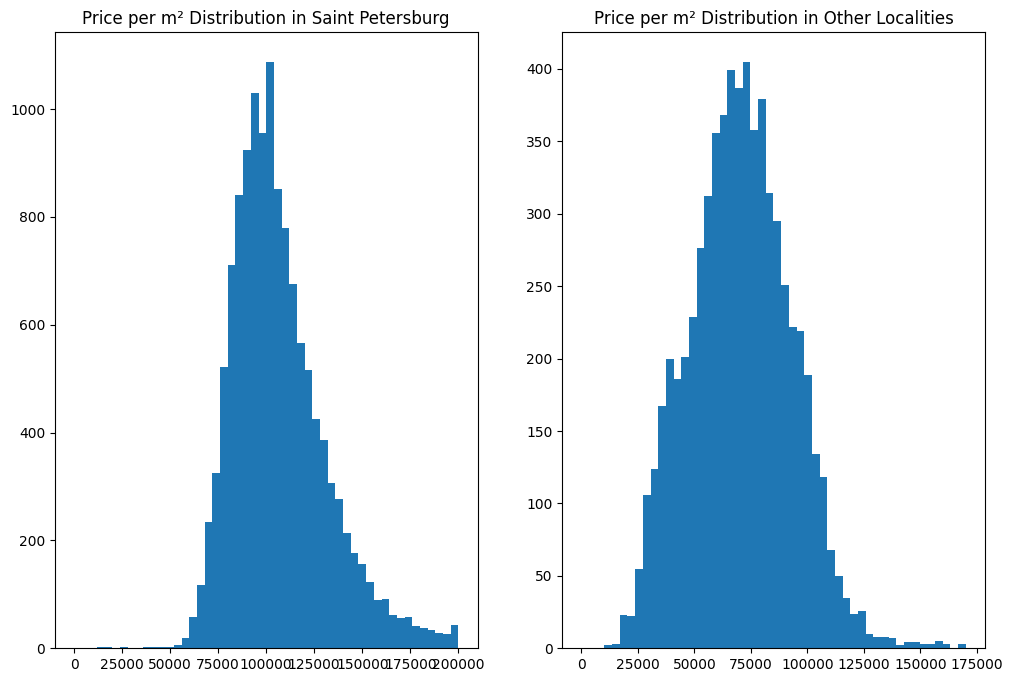

p-value for Saint Petersburg: 8.99863167583533e-84 
 p-value for other localities: 3.21939238005832e-50
Levene test p-value: 5.95318385057533e-17
Two-sample t-test p-value: 0.0


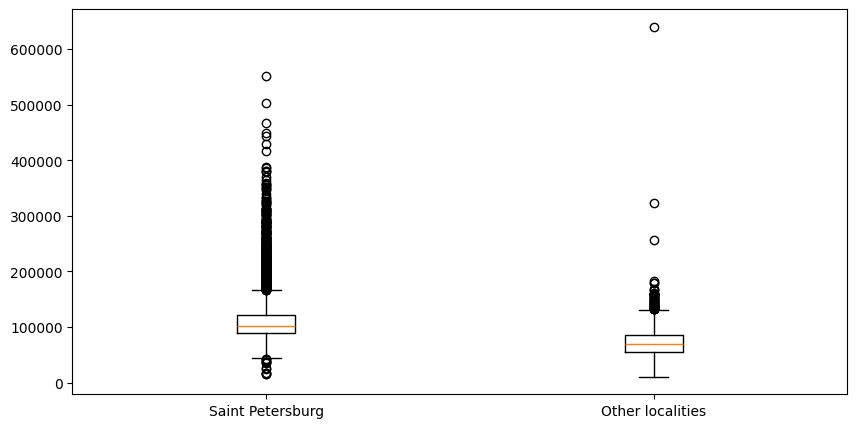

In [ ]:
from scipy import stats as st
# Part 4.2
# Step 1: Create the two groups
saint = df[(df['locality_name']=='Санкт-Петербург')]
not_saint =  df[(df['locality_name'] != 'Санкт-Петербург')]
# Step 2: Remove rows with missing values in price_per_sqm
saint = saint.dropna(subset=['price_per_sqm']).reset_index()
not_saint=  not_saint.dropna(subset=['price_per_sqm']).reset_index()
# Step 3: Check distribution normality
fig,ax = plt.subplots(1,2,figsize = (12,8))
ax[0].hist(saint['price_per_sqm'],bins= 50,range=(0,200000))
ax[1].hist(not_saint['price_per_sqm'],bins = 50,range=(0,170000))
ax[0].set_title('Price per m² Distribution in Saint Petersburg')
ax[1].set_title('Price per m² Distribution in Other Localities')
plt.show()
# Normality is assessed only within the specified range
# Method 2: Shapiro–Wilk test
s1,p1 = st.shapiro(x= saint['price_per_sqm'])
s2,p2 = st.shapiro(x= not_saint['price_per_sqm'])
print('p-value for Saint Petersburg:',p1,'\n','p-value for other localities:',p2)
# Both p-values < 0.05, indicating non-normal distributions
# Test equality of variances
s3, p3 = st.levene(saint['price_per_sqm'], not_saint['price_per_sqm'])
print('Levene test p-value:',p3) # p-value < 0.05 indicates unequal variances

# Step 4: t-test (if neither assumption is met, a two-sample t-test is not formally appropriate,
# but it is performed as required by the assignment)
t,p=st.ttest_ind(saint['price_per_sqm'],not_saint['price_per_sqm'],alternative='greater') # Saint Petersburg is expected to be higher
print('Two-sample t-test p-value:',p)
# Step 5: Interpretation
# p-value ≈ 0 < 0.05 → statistically significant difference between the mean price per m² in Saint Petersburg and other localities
# Specifically, the average price per m² in Saint Petersburg is substantially higher than in other localities
# Step 6: Visualise and compare prices using a boxplot
plt.figure(figsize = (10,5))
plt.boxplot([saint['price_per_sqm'], not_saint['price_per_sqm']], labels=['Saint Petersburg', 'Other localities'])
plt.show()

**Boxplot Findings**

Saint Petersburg has a substantially higher price per square metre:

- Saint Petersburg median ≈ RUB 100,000/m² versus approximately RUB 70,000/m² elsewhere.
- The Saint Petersburg interquartile range (box) is wider, indicating greater price variation.
- Both groups contain numerous upper outliers (very high prices).

→ **Conclusion:** The price per square metre in Saint Petersburg is considerably higher than in other localities, consistent with the hypothesis test.

## Part 5. Overall Conclusions and Report

### Part 5.1. Tasks

1. **Analyse seasonality in the real estate market:**
   - Identify the months with the highest and lowest listing activity;
   - Check whether seasonality is associated with prices (for example, whether prices rise in spring).

2. **Summarise the main findings:**
   - Which factors have the strongest relationship with price, based on charts and correlations?
   - How does price change with distance from the city centre?
   - Was the open-plan hypothesis supported by the Z-test?
   - Was the price difference between Saint Petersburg and other localities supported by the t-test?
   - Is there seasonality in prices and listing counts?
   - How does ceiling height relate to apartment value?

3. Formulate 3–5 practical recommendations for a property valuation system. For example:
   - “Price per square metre decreases by X% for each kilometre farther from the centre.”
   - “Listings peak in [months], when prices may be Y% lower.”
   - “Apartments with ceilings above 2.7 m cost Z% more, all else being equal.”

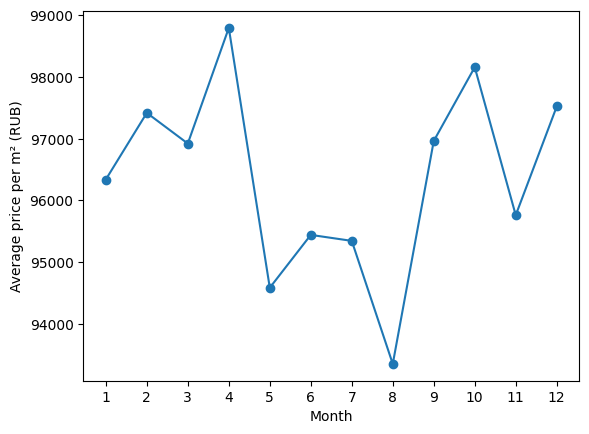

In [ ]:
# Step 5.1a: Seasonality analysis
# According to the heatmap (Part 3), activity peaks in March–April (spring) and October–November (autumn).
# Activity is lowest in June–August (summer) and January (start of the year).

# Step 5.1b: Relationship between seasonality and prices
monthly_price = df.groupby('last_month_exposition')['price_per_sqm'].mean().reset_index()
plt.plot(monthly_price['last_month_exposition'],monthly_price['price_per_sqm'] ,marker='o')
plt.xlabel('Month')
plt.ylabel('Average price per m² (RUB)')
plt.xticks(range(1,13))
plt.show()
# Price per m² is highest in September–October (autumn) and lower in summer —
# supply rises in spring (many listings), but prices respond with a delay and increase in autumn

### Part 5.2. Summary of Main Findings

**1. Factors most strongly related to price:**  
`total_area` has the strongest correlation with price (r = 0.7). The other features (`rooms`, `kitchen_area`, `ceiling_height`) have considerably weaker correlations.

**2. Price changes with distance from the centre:**  
Price per square metre drops sharply within the first 5 km, from approximately RUB 119,000 to RUB 40,000–50,000. Beyond 5 km, the price stabilises and declines more slowly. After 40 km, it rises slightly, possibly due to demand for suburban properties and dacha construction.

**3. Open-plan hypothesis (Z-test):**  
p-value ≈ 2.76e-08 < 0.05, so H₀ is rejected. The proportion of open-plan apartments in high-rise buildings (≥10 floors) is statistically significantly higher than in low-rise buildings (≤5 floors).

**4. Saint Petersburg price hypothesis (t-test):**  
p-value ≈ 0 < 0.05, so H₀ is rejected. The price per square metre in Saint Petersburg (median ≈ RUB 100,000) is substantially higher than in other localities (median ≈ RUB 70,000).

**5. Seasonality:**
- Listing counts: highest in March–April and October–November; lowest in June–August and January.
- Price per square metre: highest in autumn (September–October), lower in summer and early in the year.
- Observation: supply increases sharply in spring, but prices rise later, in autumn, when supply falls and demand remains.

**6. Ceiling height and price:**  
The overall correlation between `ceiling_height` and `last_price` is low. However, the violin plot suggests that top-floor apartments—which may have higher ceilings—have a higher price per square metre than first-floor and other apartments.

### Part 5.3. Practical Recommendations for a Property Valuation System

1. **Area is a key pricing factor:** Price per square metre decreases as total area increases. The valuation system should include `total_area` as a core variable (correlation with price: r = 0.7).

2. **Location matters:** Price per square metre drops sharply within the first 5 km from the city centre.

3. **Summer may be a favourable time to buy:** Price per square metre is lower in June–August while supply remains available, which may give buyers more room to negotiate than in autumn.

4. **Saint Petersburg may require a separate pricing model:** Price per square metre is approximately 30% higher than in nearby localities, so a single valuation model for the entire region may not be appropriate.

5. **Open-plan layouts in high-rise buildings:** The share of open-plan apartments is statistically significantly higher in buildings with ≥10 floors. A valuation model may need to account for layout type in modern high-rise buildings.

## Additional Tasks

1. **Analyse how ceiling height relates to price:**
   - Create a violin plot (`sns.violinplot`) of `price_per_sqm` by ceiling-height category: “standard” (2.5–2.7 m), “high” (>2.7 m), and “low” (<2.5 m);
   - Compare price distributions across categories;
   - Draw a conclusion about the relationship between ceiling height and apartment value.

2. **Multivariate correlation analysis:**
   - Create a correlation matrix for `last_price`, `total_area`, `rooms`, `living_area`, `kitchen_area`, `ceiling_height`, `distance_km`, and `price_per_sqm`;
   - Identify 3–4 pairs with the strongest positive and negative correlations;
   - Visualise the correlations with a heatmap.

3. **Anomaly and outlier analysis:**
   - Use the interquartile range (IQR) method to identify unusually high or low prices relative to area;
   - Identify apartments with `price_per_sqm` outside Q1 − 1.5×IQR and Q3 + 1.5×IQR;
   - Examine their characteristics (locality, area, floor, year built) and suggest possible explanations, such as luxury renovation, poor condition, or a unique location.

**Deliverable:** An expanded report with charts and additional tables, including a ceiling-height violin plot, a correlation heatmap, a list of anomalous apartments with brief analysis, and 2–3 additional practical recommendations for valuation (for example, “apply an upward adjustment of X% when valuing apartments with ceilings above 2.8 m”).

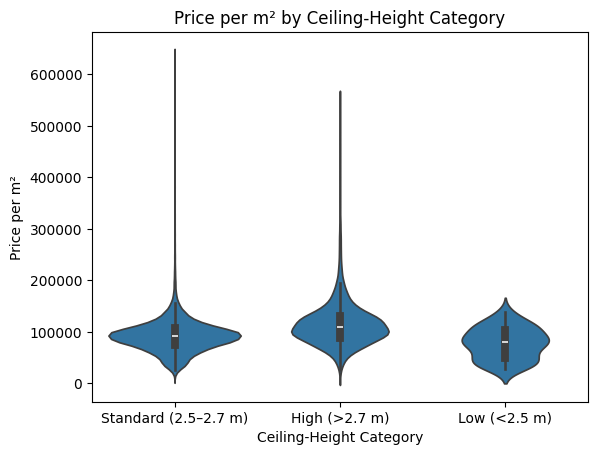

In [ ]:
# Additional task 1: Create three ceiling-height categories
conditions = [df['ceiling_height'] < 2.5,df['ceiling_height'] > 2.7]
choices = ['Low (<2.5 m)', 'High (>2.7 m)']
df['ceiling_category'] = np.select(conditions, choices, default='Standard (2.5–2.7 m)')

# Violin plot
sns.violinplot(data=df, x='ceiling_category', y='price_per_sqm')
plt.title('Price per m² by Ceiling-Height Category')
plt.xlabel('Ceiling-Height Category')
plt.ylabel('Price per m²')
plt.show()

**Findings: Ceiling Height and Price**

- **High ceilings (>2.7 m):** The widest distribution, with many observations and numerous high-price outliers (up to approximately RUB 750,000/m²); the median is slightly higher than for the standard category.
- **Standard ceilings (2.5–2.7 m):** The median is similar to the high-ceiling category, but there are fewer outliers; values are more concentrated around RUB 100,000/m².
- **Low ceilings (<2.5 m):** The narrowest distribution, a lower median of approximately RUB 80,000/m², and the smallest spread.

→ Overall, higher ceilings appear to be associated with a higher price per square metre and greater price variation.

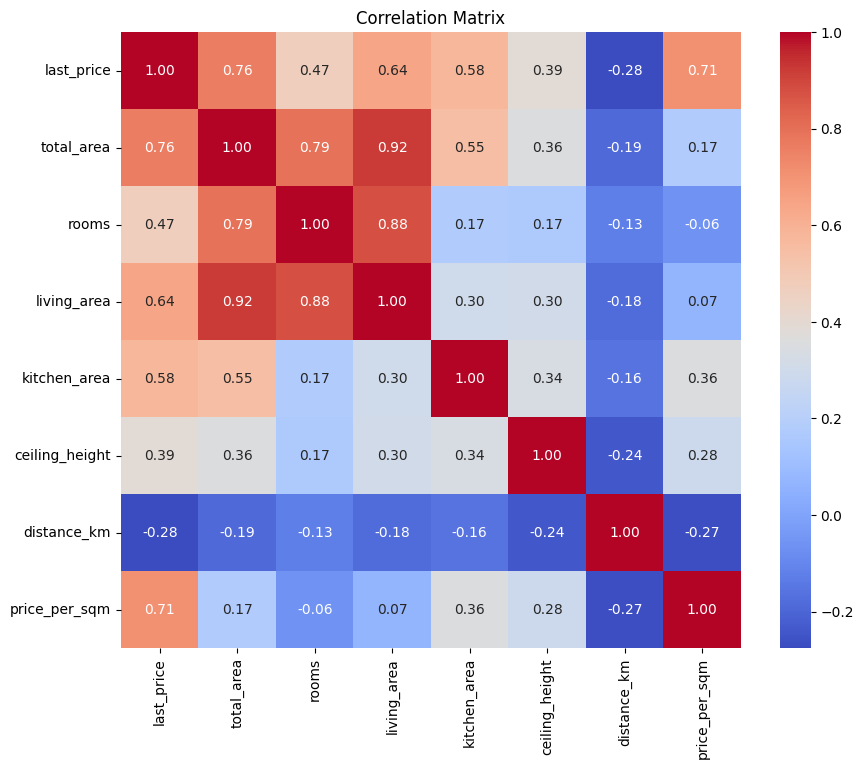

In [ ]:
# Additional task 2: Correlation matrix
corr = df[['last_price', 'total_area', 'rooms', 'living_area','kitchen_area', 'ceiling_height', 'distance_km', 'price_per_sqm']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


**Findings: Correlation Matrix**

**Strongest positive correlations:**
- `total_area` and `living_area`: r = 0.92 — total and living area are almost proportional.
- `rooms` and `living_area`: r = 0.88 — more rooms are associated with greater living area.
- `total_area` and `rooms`: r = 0.79 — apartments with more rooms tend to have a larger total area.
- `last_price` and `total_area`: r = 0.77 — area is one of the most important factors associated with total price.

**Overall observation:** `price_per_sqm` is strongly correlated with `last_price` (0.72) but weakly correlated with `total_area` (0.20). This suggests that price per square metre may depend more on location and property quality than on area alone.

In [ ]:
# Additional task 3: Detect outliers using the IQR method
Q1 = df['price_per_sqm'].quantile(0.25)
Q3 = df['price_per_sqm'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Filter outliers
outliers = df[(df['price_per_sqm'] < lower) | (df['price_per_sqm'] > upper)]

print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"Threshold values: [{lower} , {upper}]")
print(f"Number of outliers: {len(outliers)}")
print(f'Apartments with price per m² outside the lower and upper bounds:', outliers.index)
# Outlier characteristics
print(outliers[['locality_name', 'total_area', 'floor', 'price_per_sqm', 'cityCenters_nearest',
                'ceiling_height', 'rooms']].describe())


Q1=76923.08, Q3=111696.74250000001, IQR=34773.662500000006
Threshold values: [24762.586249999993 , 163857.23625000002]
Number of outliers: 720
Apartments with price per m² outside the lower and upper bounds: Index([   43,    51,    63,   121,   170,   185,   276,   282,   375,   379,
       ...
       23393, 23394, 23395, 23404, 23414, 23426, 23446, 23477, 23560, 23608],
      dtype='int64', length=720)
       total_area       floor  price_per_sqm  cityCenters_nearest  \
count  720.000000  720.000000     720.000000           720.000000   
mean    83.233153    5.915278  193070.475333          7750.908333   
std     37.335891    4.474908   77800.847693          4867.670720   
min     12.000000    1.000000   10507.250000           318.000000   
25%     54.457500    3.000000  170633.405000          4685.250000   
50%     75.800000    5.000000  187320.085000          6098.000000   
75%    108.000000    8.000000  220640.302500         10720.000000   
max    198.000000   25.000000  640422.350

**Findings: IQR Outlier Analysis**

**Typical range:** RUB 22,280–168,317/m²  
**Number of anomalous apartments:** 827 properties (price per square metre > RUB 168,317).

**Characteristics of anomalous apartments:**
- Average price per square metre: approximately RUB 204,600; maximum: RUB 721,519/m².
- Average area: approximately 87 m², so the high price is not explained by area alone.
- Distance to the city centre: median approximately 6 km, relatively close to the centre.
- Ceiling height: median 2.8 m; many properties have ceilings of 3.0–3.45 m, above standard.
- Number of rooms: median of 2, indicating a medium-sized apartment.

**Possible explanations:**
- Desirable locations close to the city centre (median distance only 6 km).
- High ceilings associated with the luxury segment.
- Some properties may be in luxury residential complexes.

→ The valuation system should treat this group as a separate segment rather than applying the general model, which could distort predictions for standard housing.